C:\Users\User\AppData\Local\Temp\ipykernel_33012\1431168073.py:58: RuntimeWarning: overflow encountered in divide
  rhsE = (-rx * (Dr @ H) + LIFT @ (Fscale * fluxE)) / eps
C:\Users\User\AppData\Local\Temp\ipykernel_33012\1431168073.py:36: RuntimeWarning: invalid value encountered in subtract
  dE = E_flat[vmapM] - E_flat[vmapP]
C:\Users\User\AppData\Local\Temp\ipykernel_33012\1431168073.py:59: RuntimeWarning: invalid value encountered in matmul
  rhsH = (-rx * (Dr @ E) + LIFT @ (Fscale * fluxH)) / mu
C:\Users\User\AppData\Local\Temp\ipykernel_33012\1431168073.py:89: RuntimeWarning: invalid value encountered in add
  E += rk4b[INTRK] * resE


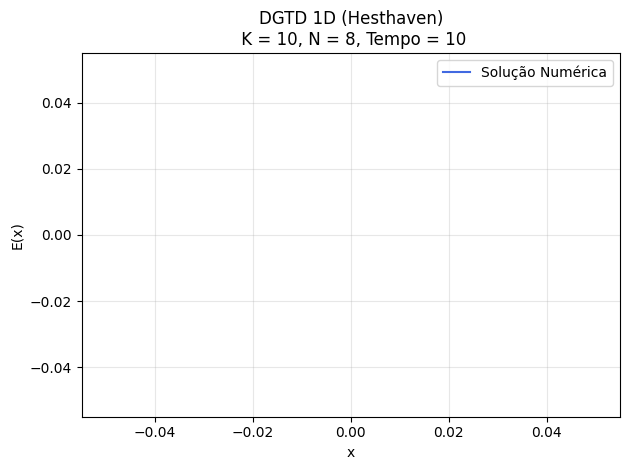

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import operadores as op
import gll1D as gll

N = 8
K = 10
Np = N + 1
Nfaces = 2
Nfp = 1
FinalTime = 10 

eps = np.ones((Np,K))*8.854*10**(-12)
mu = np.ones((Np,K))*4*np.pi*10**(-7)

Zimp = np.sqrt(mu/eps)

vmapM, vmapP, mapB, vmapB = gll.vmap(Np,K)
x, Fscale, rx, nx = gll.fator_geometrico(K,Np)
Dr, V = op.matriz_diferenciaçao(Np)
LIFT = op.Lift(Np,V)
pp = []

dE =  np.zeros((Nfp*Nfaces,K))
dH =  np.zeros((Nfp*Nfaces,K))
ZimpM = np.zeros_like(dE)
ZimpP = np.zeros_like(dE)
YimpM = np.zeros_like(dE)
YimpP = np.zeros_like(dE)

def MaxwellRHS1D(E,H):

    E_flat = E.flatten(order='F')
    H_flat = H.flatten(order='F')

    dE = E_flat[vmapM] - E_flat[vmapP]
    dH = H_flat[vmapM] - H_flat[vmapP]

    # 1. Correção: Achatar Zimp antes de usar os índices globais vmapM e vmapP
    Zimp_flat = Zimp.flatten(order='F')
    ZimpM = Zimp_flat[vmapM]
    ZimpP = Zimp_flat[vmapP]
    YimpM = 1 / ZimpM
    YimpP = 1 / ZimpP

    Ebc = -E_flat[vmapB]
    Hbc = H_flat[vmapB]
    
    # 2. Correção: Converter os índices lineares de mapB para coordenadas 2D
    mapB_2d = np.unravel_index(mapB, dE.shape, order='F')
    
    dE[mapB_2d] = E_flat[vmapB] - Ebc
    dH[mapB_2d] = H_flat[vmapB] - Hbc    

    fluxE = (nx * ZimpP * dH - dE) / (ZimpM + ZimpP)
    fluxH = (nx * YimpP * dE - dH) / (YimpM + YimpP)

    rhsE = (-rx * (Dr @ H) + LIFT @ (Fscale * fluxE)) / eps
    rhsH = (-rx * (Dr @ E) + LIFT @ (Fscale * fluxH)) / mu

    return rhsE, rhsH

def Maxwell1D(E, H):
    time = 0
    
    # 1. Correção: Inicializar ambos os resíduos
    resE = np.zeros((Np, K))
    resH = np.zeros((Np, K)) 
    
    xmin = np.min(np.abs(x[0,:] - x[1,:]))
    CFL = 0.5
    dt = CFL * xmin
    
    # 2. Correção: Converter Nsteps para inteiro
    Nsteps = int(np.ceil(FinalTime / dt)) 
    dt = FinalTime / Nsteps
    
    rk4a = [0.0, -567301805773.0/1357537059087.0, -2404267990393.0/2016746695238.0, -3550918686646.0/2091501179385.0, -3270041069962.0/2362476832515.0]
    rk4b = [1432997174477.0/9575080441755.0, 5161836677717.0/13612068292357.0, 1720146321549.0/2090206949498.0, 3134564353537.0/4481467310338.0, 2277821191437.0/14882151754819.0]
    
    for n in range(Nsteps):
        # 3. Correção: range(5) para garantir os 5 estágios (índices 0 a 4)
        for INTRK in range(5): 
            rhsE, rhsH = MaxwellRHS1D(E, H)
            
            resE = rk4a[INTRK] * resE + dt * rhsE
            resH = rk4a[INTRK] * resH + dt * rhsH
            
            E += rk4b[INTRK] * resE
            H += rk4b[INTRK] * resH
            pp.append(E.flatten(order='F'))

        time += dt
        
    return E, H

E = np.exp(-100 * (x - 0.5)**2)
H = np.zeros_like(E)

E, H = Maxwell1D(E,H)

plt.figure()
plt.title(f'DGTD 1D (Hesthaven)\n K = {K}, N = {N}, Tempo = {FinalTime}', fontsize=12)
plt.plot(x.flatten(order='F'), E.flatten(order='F'), label='Solução Numérica', color='royalblue')
#plt.plot(x.flatten(order='F'), np.sin(kx*x.flatten(order='F') - a_vel * FinalTime), '--', label='Exata', color='darkorange')
plt.ylabel('E(x)')
plt.xlabel('x')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Ajustando o eixo X
# Usamos o mesmo achatamento (flatten) que você usou no seu plot estático
x_flat = x.flatten(order='F')

# 2. Configuração inicial da figura
fig, ax = plt.subplots()
ax.set_title(f'DGTD 1D (Hesthaven) - Animação\nK = {K}, N = {N}', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.grid(alpha=0.3)

# Fixar os limites do eixo Y é crucial em animações para o gráfico não "pular"
# Como a condição inicial é um np.sin(x), os valores variam de -1 a 1.
ax.set_ylim(-1.5, 1.5) 
ax.set_xlim(x_flat.min(), x_flat.max())

# Criamos a linha vazia (pegamos o primeiro estado de pp)
linha_num, = ax.plot(x_flat, pp[0], color='royalblue', label='Solução Numérica')
ax.legend()
plt.tight_layout()

passo = 15 # Pula de 10 em 10 frames (aumente este número para acelerar mais)

def atualizar(frame_index):
    # O frame_index agora vai pular de 10 em 10
    linha_num.set_ydata(pp[frame_index])
    return linha_num,

# O range(0, len(pp), passo) gera os números: 0, 10, 20, 30...
ani = FuncAnimation(fig, atualizar, frames=range(0, len(pp), passo), interval=20, blit=True)

plt.show()

In [ ]:
def MaxwellRHS1D(E,H):

    E_flat = E.flatten(order='F')
    H_flat = H.flatten(order='F')

    dE = E_flat[vmapM] - E_flat[vmapP]
    dH = H_flat[vmapM] - H_flat[vmapP]

    ZimpM = Zimp[vmapM]
    ZimpP = Zimp[vmapP]
    YimpM = 1/ZimpM
    YimpP = 1/ZimpP

    Ebc = -E_flat[vmapB]
    dE[mapB] = E_flat[vmapB] - Ebc
    Hbc = H_flat[vmapB]
    dH[mapB] = H_flat[vmapB] - Hbc    

    fluxE = (nx * ZimpP * dH - dE) / (ZimpM + ZimpP)
    fluxH = (nx * YimpP * dE - dH) / (YimpM + YimpP)

    rhsE = (-rx * (Dr @ H) + LIFT @ (Fscale * fluxE)) / eps
    rhsH = (-rx * (Dr @ E) + LIFT @ (Fscale * fluxH)) / mu

    return rhsE, rhsH

def Maxwell1D(E,H):
    time = 0

    resE = np.zeros((Np,K))
    xmin = np.min(np.abs(x[0,:]-x[1,0]))
    CFL = 1
    dt = CFL*xmin
    Nsteps = np.ceil(FinalTime/dt)
    dt = FinalTime/Nsteps

    rk4a = [0.0, -567301805773.0/1357537059087.0, -2404267990393.0/2016746695238.0, -3550918686646.0/2091501179385.0, -1275806237668.0/842570457699.0]
    rk4b = [1432997174477.0/9575080441755.0, 5161836677717.0/13612068292357.0, 1720146321549.0/2090206949498.0, 3134564353537.0/4481467310338.0, 2277821191437.0/14882151754819.0]

    for n in range(Nsteps):
        for INTRK in range(1,5):
            rhsE, rhsH = MaxwellRHS1D(E,H)

            resE = rk4a[INTRK]*resE + dt*rhsE
            resH = rk4a[INTRK]*resH + dt*rhsH

            E += rk4b[INTRK]*resE
            H += rk4b[INTRK]*resH

        time += dt
    return E,H